### El problema del clasificador binario en forma de circulo.


In [29]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from mlp.mlp_main import MLP


# Generate data
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)


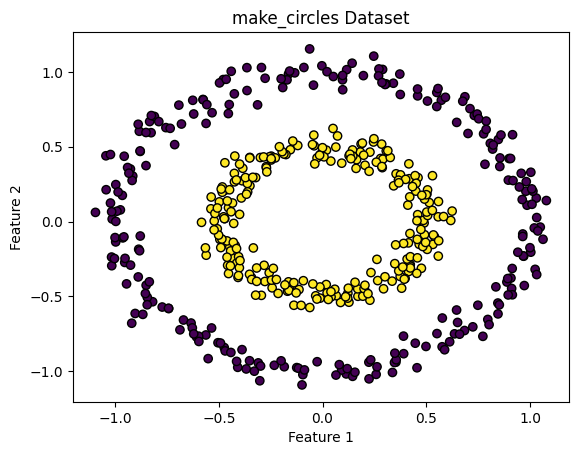

In [30]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title("make_circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [31]:
# Preparar datos

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Instanciar y entrenar el modelo MLP

mlp = MLP(
    layers=[(2, 5, "relu"), (5, 1, "sigmoid")], # Arquitectura: 2 entradas, 5 neuronas en la capa oculta, 1 salida
    learning_rate=0.01,
)

history = mlp.train(X_train, y_train, epochs=1000, batch_size=32, error_tolerance=0.001)

Epoch 0, MSE: 0.1312116121884342
Epoch 10, MSE: 0.11300987841908247
Epoch 20, MSE: 0.10278788081698156
Epoch 30, MSE: 0.0944119320831856
Epoch 40, MSE: 0.08712898574692522
Epoch 50, MSE: 0.078869603761454
Epoch 60, MSE: 0.0685085585165353
Epoch 70, MSE: 0.056654837992612325
Epoch 80, MSE: 0.04417628601156851
Epoch 90, MSE: 0.032535910519967653
Epoch 100, MSE: 0.023862793397439207
Epoch 110, MSE: 0.018264194721841084
Epoch 120, MSE: 0.01448585947495386
Epoch 130, MSE: 0.011814135739996474
Epoch 140, MSE: 0.00990255395462162
Epoch 150, MSE: 0.008445466829430459
Epoch 160, MSE: 0.0073254546996745305
Epoch 170, MSE: 0.006420754072600563
Epoch 180, MSE: 0.005698311001465144
Epoch 190, MSE: 0.005113642372475081
Epoch 200, MSE: 0.004630659018536154
Epoch 210, MSE: 0.004225408450980989
Epoch 220, MSE: 0.003881037007508295
Epoch 230, MSE: 0.00358510486711033
Epoch 240, MSE: 0.003327216990530217
Epoch 250, MSE: 0.003097821210281372
Epoch 260, MSE: 0.002891676963897985
Epoch 270, MSE: 0.002705401

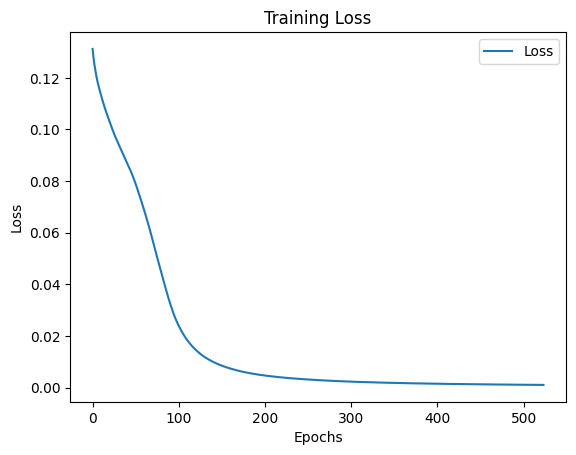

In [40]:
# Funcion de perdida

plt.plot(history, label='Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
# Validar el modelo

y_pred = mlp.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_labels))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        57

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

